# Testing UOT on single cell data
Due to the issues that come with normalizing the data, we're interested to see if unbalanced optimal transport can fix certain concerns. This also means we'll have to determine the calculation times and see if we can optimize the computation time of these calculations.

## Imports

In [ ]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
import re
from time import perf_counter
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, hic_ot_source_to_targets, fetch_region, get_cool_name, bin_contact_map

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_times'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Selecting Data

In [2]:
### Importing chr1s ###
clrs = import_cool_dir(sc_dir)
chr1s = []
clr_names = []
for clr in clrs:
    chr1s.append(fetch_region(clr, "chr1"))
    clr_names.append(get_cool_name(clr))

In [3]:
### Selecting source and targets ###
np.random.seed(42)
source_index = np.random.randint(0, len(chr1s)-1)
target_indices = np.random.randint(0, len(chr1s)-1, 10)
target_indices

source = chr1s[source_index]
source_name = clr_names[source_index]
targets = []
target_names = []
for index in target_indices:
    targets.append(chr1s[index])
    target_names.append(clr_names[index])

## Helper Functions

In [ ]:
def calc_ot(res: int, thres: float=0, unbalanced: float|None=None):
    '''
        Calculates OT scores from source to targets using provided
        resolution, threshold and unbalanced parameter.
        Also updates time file.

        Function is very specific to this notebook.

        Parameters 
        ----------
        res : int
            Reolution to bin the data to.
        thres : float
            Threshold to use for the data.
        unbalanced : float
            Unbalanced parameter to use
            Default = None, uses balanced OT.
        
        Returns
        -------
        ot_results : pd.DataFrame
            OT results as a dataframe.
    '''
    # Binning
    source_bin = bin_contact_map(source, res)
    targets_bin = []
    for target in targets:
        targets_bin.append(bin_contact_map(target, res))
    
    # Starting counter
    time = perf_counter()

    # OT
    if unbalanced is None:
        if thres == 0:
            ot_results_list = [hic_ot_source_to_targets(source_bin, targets_bin, norm='sum')]
        else:
            ot_results_list = [hic_ot_source_to_targets(source_bin, targets_bin, cut_off=thres, type="percentile", norm="sum")]
    else:
        if thres == 0:
            ot_results_list = [hic_ot_source_to_targets(source_bin, targets_bin, norm='max', unbalanced=unbalanced)]
        else:
            ot_results_list = [hic_ot_source_to_targets(source_bin, targets_bin, cut_off=thres, type="percentile", norm='max', unbalanced=unbalanced)]
    
    # Stopping timer
    time = perf_counter() - time

    # Saving OT to df
    ot_results = pd.DataFrame(ot_results_list, index=[source_name], columns=target_names)

    # Saving df to csv
    if unbalanced is None:
        filename = f"sc_uot_tests_{res}mb_{thres}thres_balanced.csv"
        time_file = "sc_uot_tests_comptimes_balanced.csv"
    else:
        filename = f"sc_uot_tests_{res}mb_{thres}thres_{unbalanced}unbalanced.csv"
        time_file = f"sc_uot_tests_comptimes_{unbalanced}unbalanced.csv"
    ot_results.to_csv(f"{save_dir}/{filename}")

    # Updating time file
    time_path = f"{save_dir}/{time_file}"

        # Cast to strings to ensure proper indexing
    res = str(res)
    thres = str(thres)

        # Make or import csv
    if os.path.exists(time_path):
        df_calc = pd.read_csv(time_path, index_col=0)
        df_calc.index = df_calc.index.astype(str)
    else:
        df_calc = pd.DataFrame()

        # Insert value in row
    df_calc.at[thres, res] = time

        # Save to CSV
    df_calc.to_csv(time_path)

    return ot_results

def load_sc_files(path: str):
    '''
    Load all sc_uot_tests_comptimes_*.csv files into pandas DataFrames.

    Parameters
    ----------
    path : str
        Path to folder containing csvs.

    Returns
    -------
    dfs : dict
        Dictionary containing all csvs as dataframes.
        Keys are:
            - 'balanced'
            - ('unbalanced', reg_m)  where reg_m is a float
        Values are pandas DataFrames.
    '''

    dir = Path(path)
    dfs = {}

    pattern = re.compile(
        r"sc_uot_tests_comptimes_(balanced|([0-9]*\.?[0-9]+)unbalanced)\.csv"
    )

    for file in dir.glob("sc_uot_tests_comptimes_*.csv"):
        match = pattern.match(file.name)
        if not match:
            continue

        if match.group(1) == "balanced":
            key = "balanced"
        else:
            reg_m = float(match.group(2))
            key = ("unbalanced", reg_m)

        # Read csv
        df = pd.read_csv(file, index_col=0)

        # Convert index/columns to numeric
        df.index = pd.to_numeric(df.index, errors="coerce")
        df.columns = pd.to_numeric(df.columns, errors="coerce")

        dfs[key] = df

    return dfs

def plot_fixed_res(dfs: dict, res: int, logy=False):
    '''
    Plot computation time vs threshold for a fixed resolution.

    Parameters
    ----------
    dfs : dict
        Output of load_sc_uot_csvs()
    res : int
        Resolution to plot
    logy : bool, optional
        Whether to use log scale for y-axis
    '''

    plt.figure()

    for key, df in dfs.items():

        thresholds = df.index
        times = df[res]

        if key == "balanced":
            label = "balanced"
            marker = "o"
            linestyle = "-"
            
        else:
            _, reg_m = key
            label = f"unbalanced (reg_m={reg_m})"
            marker = "o"
            linestyle = "--"

        plt.plot(thresholds, times, label=label, marker=marker, linestyle=linestyle)

    plt.xlabel("Threshold (nth percentile removed)")
    plt.ylabel("Computation time (s)")
    plt.title(f"Computation time vs threshold (resolution = {res}Mb)")
    plt.legend()
    plt.grid(True)

    if logy:
        plt.yscale("log")

    plt.tight_layout()

def load_method_results(path: str):
    '''
        Takes all OT results in the given path and compiles them
        into a list of flattened vectors.

        Parameters
        ----------
        path : str
            Path to OT results csv files.
        
        Returns
        -------
        methods : dict
            Dictionary of method results, accesible by metadata as 
            (kind, res, thres, reg_m).
    '''
    dir = Path(path)
    methods = {}

    # Patterns
    balanced_pattern = re.compile(
        r"sc_uot_tests_(\d+)mb_(\d+)thres_balanced\.csv"
    )
    unbalanced_pattern = re.compile(
        r"sc_uot_tests_(\d+)mb_(\d+)thres_([0-9]*\.?[0-9]+)unbalanced\.csv"
    )

    for file in dir.glob("sc_uot_tests_*.csv"):
        name = file.name

        # Determine balanced or unbalanced
        bmatch = balanced_pattern.match(name)
        umatch = unbalanced_pattern.match(name)

        if bmatch:
            res = int(bmatch.group(1))
            thres = int(bmatch.group(2))
            reg_m = None
            kind = "balanced"

        elif umatch:
            res = int(umatch.group(1))
            thres = int(umatch.group(2))
            reg_m = float(umatch.group(3))
            kind = "unbalanced"
        
        else:
            continue
        
        # Save results to df
        df = pd.read_csv(file, index_col=0)
        
        # Convert to vector
        vec = df.to_numpy().ravel()

        # Add to methods registry
        method_id = (kind, res, thres, reg_m)
        methods[method_id] = vec

    return methods

def calc_corr_matrix(methods: dict):
    '''
        Computes the Pearson correlation coefficient between
        all methods, pairwise.

        Parameters
        ----------
        methods : dict
            Dictionary with all methods accessible via
            (kind, res, thres, reg_m).

        Returns
        -------
        corr_df : df
            Dataframe for all pairwise comparisons between methods
    '''
    method_ids = list(methods.keys())
    n = len(method_ids)

    # Initialize empty df
    corr = np.zeros((n, n))

    # Loop through methods and indices to calculate r
    for i, mi in enumerate(method_ids):
        vi = methods[mi]

        for j, mj in enumerate(method_ids):
            if j < i:
                corr[i, j] = corr[j, i]
                continue
            
            r = pearsonr(vi, methods[mj])[0]
            corr[i, j] = corr[j, i] = r
    
    # Create dataframe
    corr_df = pd.DataFrame(
        corr,
        index=method_ids,
        columns=method_ids
    )

    return corr_df


def plot_grouped_heatmap(corr_df : pd.DataFrame, kind: str="balanced", reg_m: float|None=None):
    """
    Plot a heatmap for a specific group of methods within the same
    kind (balanced or unbalanced).

    Parameters
    ----------
    corr_df : pd.DataFrame
        Method-method correlation matrix.
    kind : str
        "balanced" or "unbalanced"
        Default = 'balanced'
    reg_m : float
        Reg_m used for the methods. Only for unbalanced methods
        Default = None
    """
    # Filter method IDs for this group
    method_ids = [
        mid for mid in corr_df.index
        if mid[0] == kind and (kind == "balanced" or mid[3] == reg_m)
    ]

    if len(method_ids) == 0:
        print(f"No methods found for kind={kind}, reg_m={reg_m}")
        return

    sub_corr = corr_df.loc[method_ids, method_ids]

    # Generate readable labels
    labels = [f"{mid[1]}mb_{mid[2]}thres" for mid in method_ids]

    plt.figure(figsize=(8, 6))
    sns.clustermap(
        sub_corr,
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=-1,
        vmax=1
    )
    title = f"{kind.capitalize()} methods, 10 sc comparisons"
    if kind == "unbalanced":
        title += f" (reg_m={reg_m})"
    plt.suptitle(title, y=1.02, fontweight='bold')
    plt.tight_layout()

def plot_grouped_heatmap_cross(corr_df : pd.DataFrame, res : int, thres : int):
    """
    Plot a heatmap for a specific group of methods across different
    kinds.

    Parameters
    ----------
    corr_df : pd.DataFrame
        Method-method correlation matrix.
    res : int
        Desired resolution
    thres : int
        Desired threshold
    """
    # Filter method IDs for this group
    method_ids = [
        mid for mid in corr_df.index
        if mid[1] == res and mid[2] == thres
    ]

    if len(method_ids) == 0:
        print(f"No methods found for res={res}, thres={thres}")
        return

    sub_corr = corr_df.loc[method_ids, method_ids]

    # Generate readable labels
    labels = [f"{mid[0]}OT" if mid[3] is None else f"{mid[0]}OT_{mid[3]}reg_m"
              for mid in method_ids]

    plt.figure(figsize=(8, 6))
    sns.clustermap(
        sub_corr,
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=-1,
        vmax=1
    )
    title = f"{res}Mb_{thres}thres methods, 10 sc comparisons"
    plt.suptitle(title, y=1.02, fontweight='bold')
    plt.tight_layout()

## Looping through Balanced

In [23]:
# Setting parameters
res_list = [8, 4, 2, 1]
thres_list = [0, 75, 90, 95]

# Looping
for res in res_list:
    for thres in thres_list:
        calc_ot(res, thres)

## Looping through unbalanced (1)

In [ ]:
# Setting parameters
res_list = [1]
thres_list = [75, 90, 95]
unbalanced = 1

# Looping
for res in res_list:
    for thres in thres_list:
        calc_ot(res, thres, unbalanced)

## Looping through unbalanced (0.1)

In [5]:
# Setting parameters
res_list = [1]
thres_list = [75, 90, 95]
unbalanced = 0.1

# Looping
for res in res_list:
    for thres in thres_list:
        calc_ot(res, thres, unbalanced)

## Looping through unbalanced (10)

In [5]:
# Setting parameters
res_list = [1]
thres_list = [75, 90, 95]
unbalanced = 10

# Looping
for res in res_list:
    for thres in thres_list:
        calc_ot(res, thres, unbalanced)

## Plotting Times

In [ ]:
### Importing results ###
dfs = load_sc_files(save_dir)
print(dfs)

{'balanced':            8         4         2          1
0   0.059652  0.586015  6.986841  61.210392
75  0.004019  0.025341  0.263297   2.352418
90  0.001813  0.004970  0.034838   0.237107
95  0.001665  0.002547  0.009996   0.054852, ('unbalanced', 0.1):            8          4           2           1
0   1.121736  22.225042  368.346444         NaN
75  0.083205   1.461421   14.319758  129.787685
90  0.024858   0.161564    1.143795   10.864574
95  0.006647   0.013266    0.175170    0.706161, ('unbalanced', 1.0):            8          4           2           1
0   3.507140  38.416497  426.245504         NaN
75  0.304696   1.834521   15.060203  124.335418
90  0.057246   0.319965    2.024134   12.819605
95  0.027069   0.059546    1.420738    2.882522, ('unbalanced', 10.0):            8          4           2           1
0   3.739726  40.028445  428.932230         NaN
75  0.318829   1.810300   15.167738  122.211922
90  0.114223   0.342140    1.984984   12.831459
95  0.064450   0.144446    1

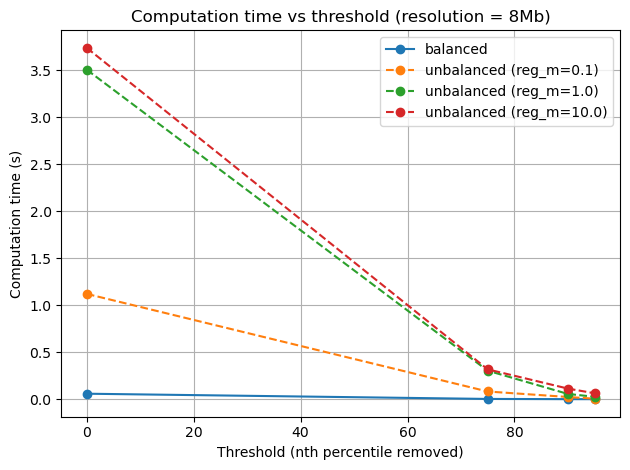

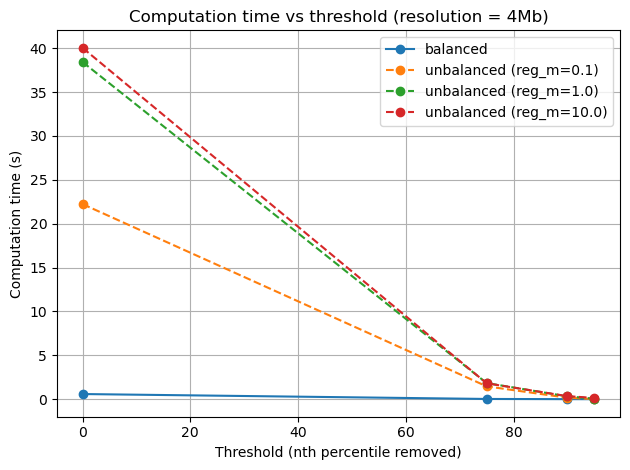

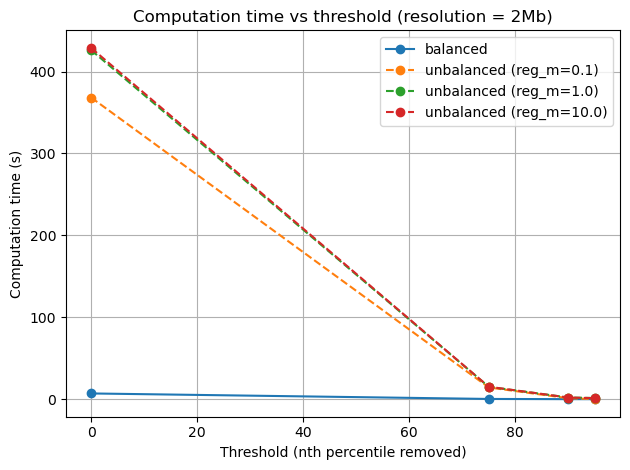

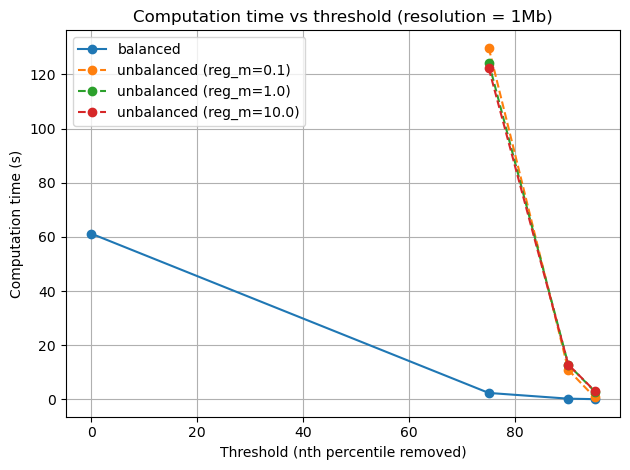

In [26]:
### Comparisons per Resolution ###
resolutions = [8, 4, 2, 1]
for res in resolutions:
    plot_fixed_res(dfs, res)

## Comparing values

In [60]:
### Adding all results to registry ###
registry = load_method_results(save_dir)
registry

{('balanced',
  1,
  75,
  None): array([ 756.55205615,  291.09943864,  966.76010285,  804.48642399,
        1255.26858446,  762.16307624,  279.04525335, 1139.79542566,
         907.59155956, 1198.94298285]),
 ('balanced',
  4,
  0,
  None): array([ 77.72622056,  25.09367829,  48.82794791,  59.79218492,
         49.30054238,  42.53338172,  84.12959817, 115.68888689,
        140.49487721,  87.95988496]),
 ('balanced',
  8,
  95,
  None): array([112.4358353 ,  40.79953258,  45.81790468,  28.23419341,
         94.5774399 ,  44.00807463,  78.59005715, 166.89844454,
         92.2034107 ,  81.1287031 ]),
 ('unbalanced',
  2,
  75,
  1.0): array([ 7.64604509,  7.75955804,  9.73475034,  9.76855458, 14.49442874,
         6.5586794 ,  8.57606298,  7.50899074,  9.46104532,  7.28816177]),
 ('unbalanced',
  1,
  90,
  10.0): array([ 85.70484244,  68.6162125 , 115.74055622,  93.87578278,
        185.69325122,  72.67216816,  88.3682105 , 106.87519984,
         94.02115914,  72.69174371]),
 ('balanced

In [61]:
### Calculating Pearson between all methods ###
corr = calc_corr_matrix(registry)

<Figure size 800x600 with 0 Axes>

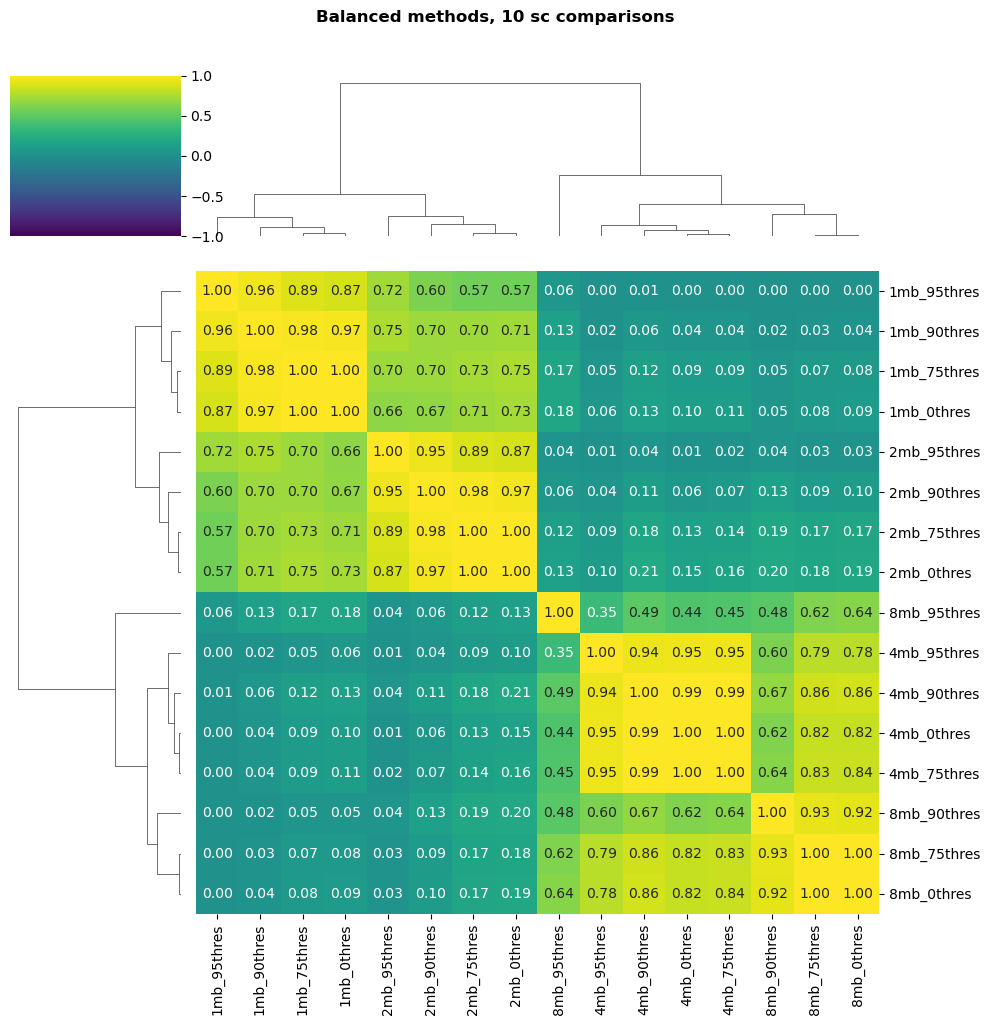

In [64]:
### Plotting balanced methods ###
plot_grouped_heatmap(corr)

<Figure size 800x600 with 0 Axes>

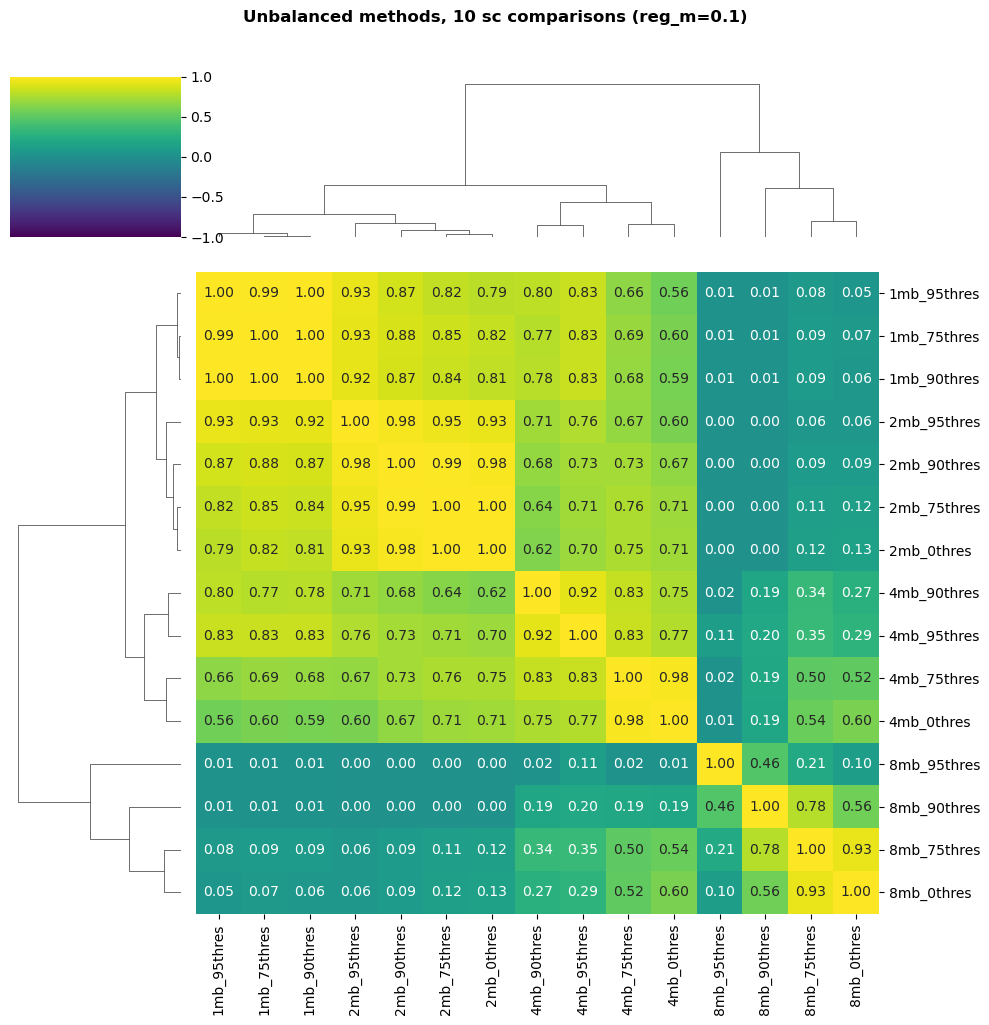

In [65]:
### Plotting reg_m = 0.1 ###
plot_grouped_heatmap(corr, kind="unbalanced", reg_m=0.1)

<Figure size 800x600 with 0 Axes>

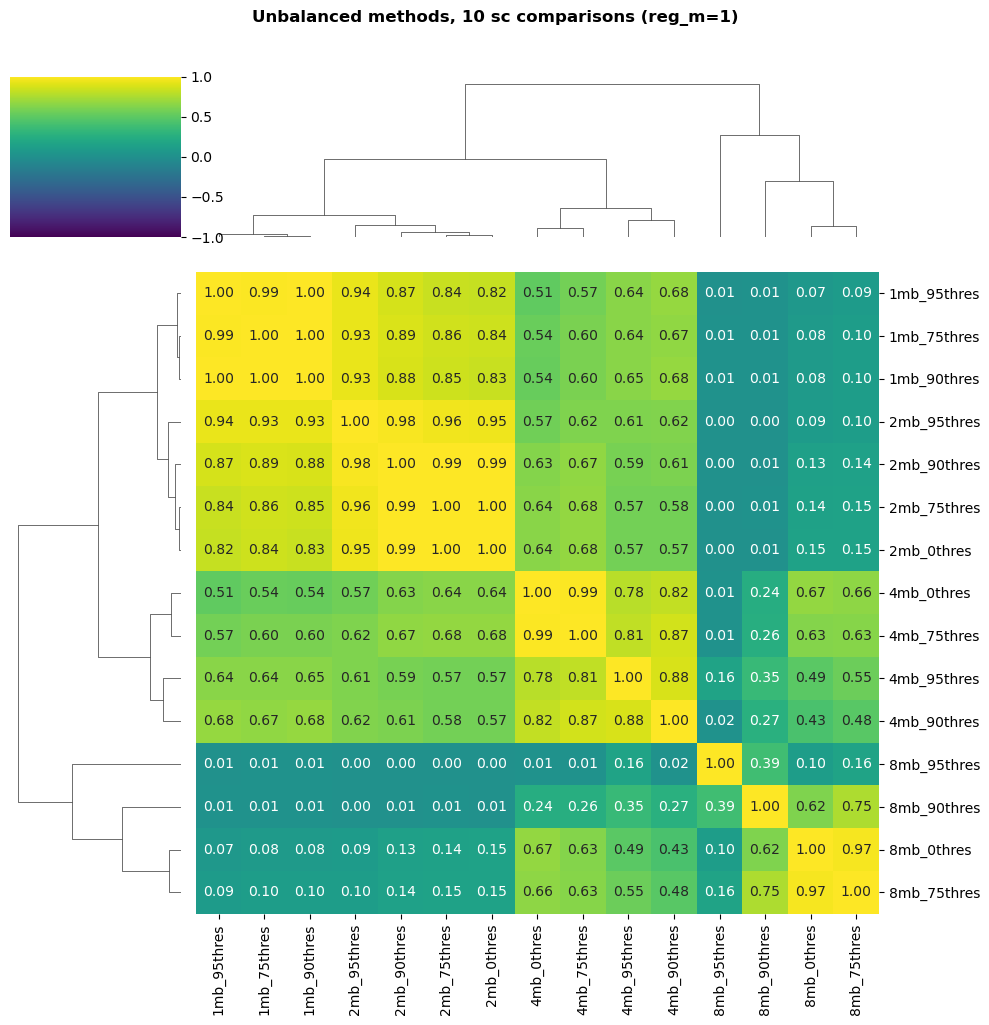

In [66]:
### Plotting reg_m = 0.1 ###
plot_grouped_heatmap(corr, kind="unbalanced", reg_m=1)

<Figure size 800x600 with 0 Axes>

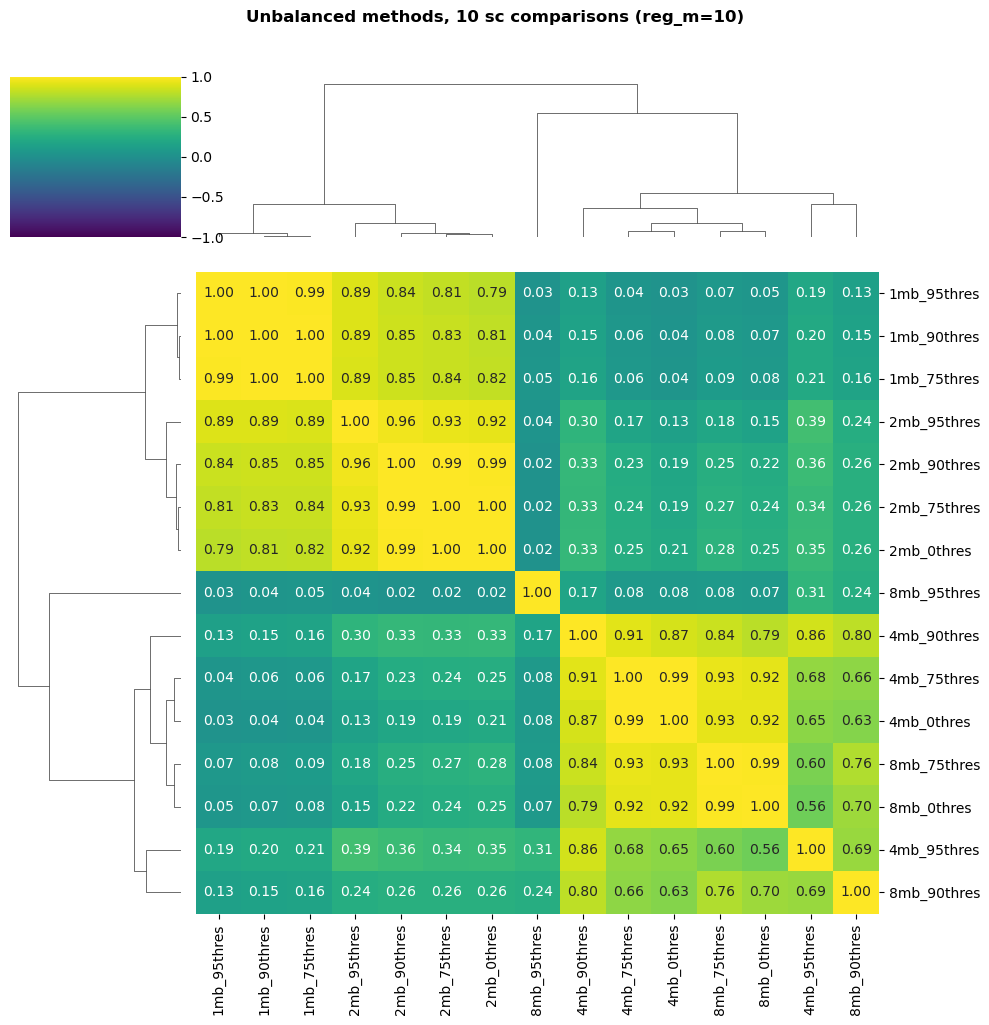

In [67]:
### Plotting reg_m = 0.1 ###
plot_grouped_heatmap(corr, kind="unbalanced", reg_m=10)

<Figure size 200x100 with 0 Axes>

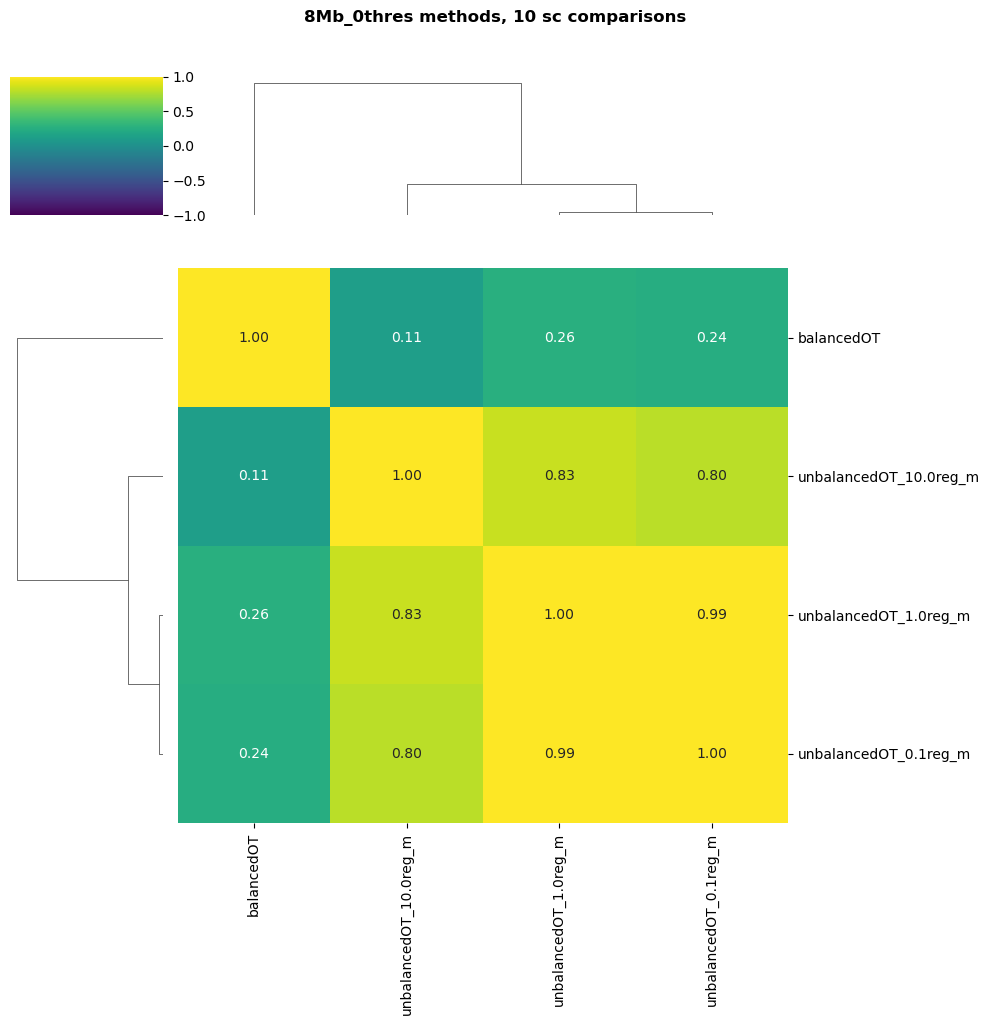

In [83]:
### Plotting between kinds ###
plot_grouped_heatmap_cross(corr, 8, 0)